# Week 11 - Feature Fusion Classifier



## Project Context

Throughout this project, we explored several audio representations individually, including MFCCs and Mel-spectrograms.

In this notebook, we combine multiple handcrafted audio features into a single feature vector.

The goal is to investigate whether combining complementary information improves genre classification performance.

## Goals

By the end of this notebook, we can:

- extract multiple complementary audio features
- combine them into one feature vector
- train a Random Forest classifier on the fused representation
- evaluate the resulting performance
- analyze which feature groups contribute most to the final model

In [1]:
import numpy as np
import pandas as pd
import librosa
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
data_path = Path("../data/raw/gtzan/Data/genres_original")

genres = [
    "rock",
    "classical",
    "jazz",
    "metal"
]

samples_per_genre = 100

In [3]:
print("Data path exists:", data_path.exists())

for genre in genres:
    genre_path = data_path / genre
    print(
        genre,
        "exists:", genre_path.exists(),
        "files:", len(list(genre_path.glob("*.wav")))
    )

Data path exists: True
rock exists: True files: 100
classical exists: True files: 100
jazz exists: True files: 100
metal exists: True files: 100


In [4]:
def summarize_feature(feature):
    """
    Summarize a time-dependent feature by mean and standard deviation.
    """
    mean = np.mean(feature, axis=1)
    std = np.std(feature, axis=1)
    return np.concatenate([mean, std])

## Feature Fusion

Instead of relying on a single feature type, we combine several complementary audio descriptors.

Each feature captures a different characteristic of the music signal.

Together, they provide a richer representation than any individual feature alone.
The extracted feature vector contains information about:

- timbre (MFCCs)
- harmony (Chroma)
- spectral characteristics (Spectral Contrast)
- rhythm (Tempo)
- signal energy (RMS)

In [5]:
def extract_audio_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    features = []

    # 1. MFCCs: timbre / sound color
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features.extend(summarize_feature(mfcc))

    # 2. Chroma: harmonic content / pitch classes
    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr,
        tuning=0
    )
    features.extend(summarize_feature(chroma))

    # 3. Spectral contrast: difference between peaks and valleys in frequency bands
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    features.extend(summarize_feature(contrast))

    # 4. Tonnetz: tonal centroid features, harmonic relations
    y_harmonic = librosa.effects.harmonic(y)
    tonnetz = librosa.feature.tonnetz(y=y_harmonic, sr=sr)
    features.extend(summarize_feature(tonnetz))

    # 5. Zero Crossing Rate: signal noisiness / percussive content
    zcr = librosa.feature.zero_crossing_rate(y)
    features.extend(summarize_feature(zcr))

    # 6. Spectral centroid: brightness
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.extend(summarize_feature(centroid))

    # 7. Spectral bandwidth: spread of frequencies
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.extend(summarize_feature(bandwidth))

    # 8. Spectral rolloff: frequency below which most energy is contained
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.extend(summarize_feature(rolloff))

    # 9. Tempo: global rhythmic descriptor
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features.append(np.asarray(tempo).item())

    return np.array(features)

## Feature Groups

The combined feature vector contains several groups:

- MFCCs: timbre and sound color
- Chroma: harmonic and pitch-class information
- Spectral Contrast: frequency band contrast
- Tonnetz: tonal relations
- Zero Crossing Rate: noisiness and transient behavior
- Spectral Centroid: brightness
- Spectral Bandwidth: frequency spread
- Spectral Rolloff: high-frequency energy distribution
- Tempo: rhythmic information

This allows the classifier to use more musical information than MFCCs alone.

## Building the Feature Dataset

Each audio file is processed using the feature extraction pipeline.

The resulting feature vectors are stored in `X`, while the corresponding genre labels are stored in `y`.

This produces a structured dataset suitable for classical machine learning algorithms.

In [6]:
X = []
y = []
file_names = []
skipped_files = []

for genre in genres:
    genre_path = data_path / genre
    files = list(genre_path.glob("*.wav"))[:samples_per_genre]

    for file in files:
        try:
            feature_vector = extract_audio_features(file)

            X.append(feature_vector)
            y.append(genre)
            file_names.append(file.name)

        except Exception as e:
            skipped_files.append(file)
            print("Skipped:", file.name, "|", e)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Skipped files:", len(skipped_files))

/tmp/ipykernel_5531/1183583312.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
/home/richard/Projects/Music-Genre-Classification-with-CNNs-and-Audio-Based-Song-Recommendation/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipped: jazz.00054.wav | 
X shape: (399, 85)
y shape: (399,)
Skipped files: 1


In [7]:
print("Number of extracted features per song:", X.shape[1])

Number of extracted features per song: 85


Compared to the previous MFCC-only classifier, each song is now represented by a significantly richer feature vector.

This allows the classifier to exploit complementary information from different aspects of the audio signal.

## Preparing Data for Machine Learning

Before training, genre labels are encoded as numerical values and the feature vectors are standardized.

Feature scaling ensures that all descriptors contribute on a comparable scale during training.

In [8]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['classical' 'jazz' 'metal' 'rock']


## Training the Feature Fusion Classifier

A Random Forest classifier is trained on the fused feature vectors.

Random Forests are particularly well suited for heterogeneous feature sets because they naturally handle different feature types and provide interpretable feature importance values.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

## Model Performance

The trained model is evaluated on the test set using accuracy, a classification report, and a confusion matrix.

The resulting performance is compared to the previous classifiers developed throughout the project.

In [12]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Feature Fusion Classifier Accuracy:", accuracy)

Feature Fusion Classifier Accuracy: 0.9


In [13]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

   classical       0.90      0.95      0.93        20
        jazz       0.89      0.80      0.84        20
       metal       0.90      0.95      0.93        20
        rock       0.90      0.90      0.90        20

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80



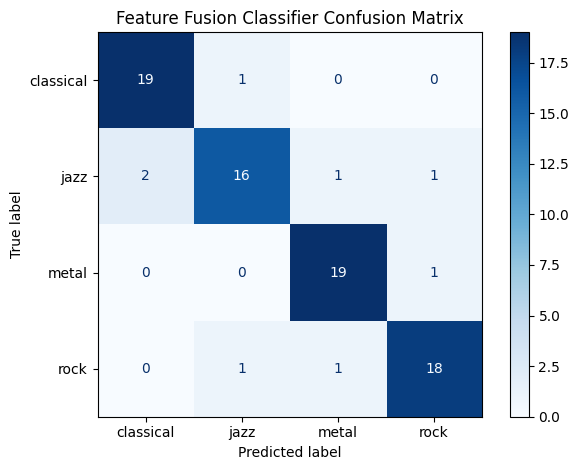

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Feature Fusion Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
results = pd.DataFrame({
    "Model": [
        "MFCC Random Forest",
        "CNN v1",
        "CNN v2",
        "Feature Fusion Random Forest"
    ],
    "Accuracy": [
        0.79,
        0.85,
        0.80,
        accuracy
    ]
})

results

,Model,Accuracy
0,MFCC Random Forest,0.79
1,CNN v1,0.85
2,CNN v2,0.80
3,Feature Fusion Random Forest,0.90


## Why Did Feature Fusion Improve Performance?

The baseline classifier relied mainly on MFCC features, which primarily describe the timbral characteristics of music.

The feature fusion approach extends this representation by incorporating harmonic, spectral, and rhythmic descriptors.

As a result, the classifier receives a more comprehensive description of each song, allowing it to distinguish genres based on multiple musical aspects instead of timbre alone.

This experiment demonstrates that carefully selected handcrafted features can still achieve excellent performance on relatively small datasets.

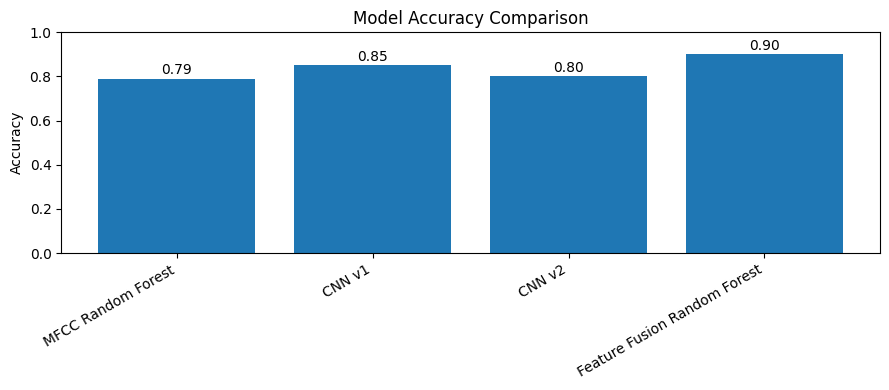

In [16]:
plt.figure(figsize=(9, 4))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30, ha="right")

for i, value in enumerate(results["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

- The feature fusion classifier achieved the highest classification accuracy among all evaluated models.
- This suggests that combining complementary handcrafted audio descriptors can outperform a relatively small CNN on this dataset.
- The result also highlights that deep learning is not always superior; for smaller datasets, carefully engineered features can provide a strong baseline.

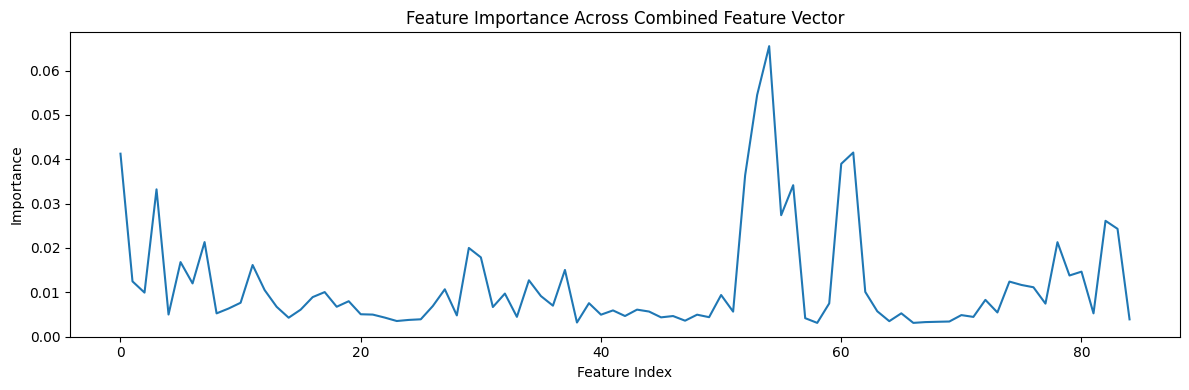

In [17]:
importances = model.feature_importances_

plt.figure(figsize=(12, 4))
plt.plot(importances)

plt.title("Feature Importance Across Combined Feature Vector")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

## Feature Group Importance

Individual feature importances can be aggregated into feature groups.

This provides a more intuitive understanding of which types of audio information are most useful for genre classification.

In [18]:
feature_groups = {
    "MFCC": 26,
    "Chroma": 24,
    "Spectral Contrast": 14,
    "Tonnetz": 12,
    "Zero Crossing Rate": 2,
    "Spectral Centroid": 2,
    "Spectral Bandwidth": 2,
    "Spectral Rolloff": 2,
    "Tempo": 1
}

In [19]:
group_importances = {}

start = 0

for group_name, group_size in feature_groups.items():
    end = start + group_size
    group_importances[group_name] = importances[start:end].sum()
    start = end

importance_df = pd.DataFrame({
    "Feature Group": group_importances.keys(),
    "Importance": group_importances.values()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature Group,Importance
2,Spectral Contrast,0.344010
0,MFCC,0.274170
1,Chroma,0.184907
3,Tonnetz,0.069015
7,Spectral Rolloff,0.050428
5,Spectral Centroid,0.035087
6,Spectral Bandwidth,0.019903
4,Zero Crossing Rate,0.018582
8,Tempo,0.003898


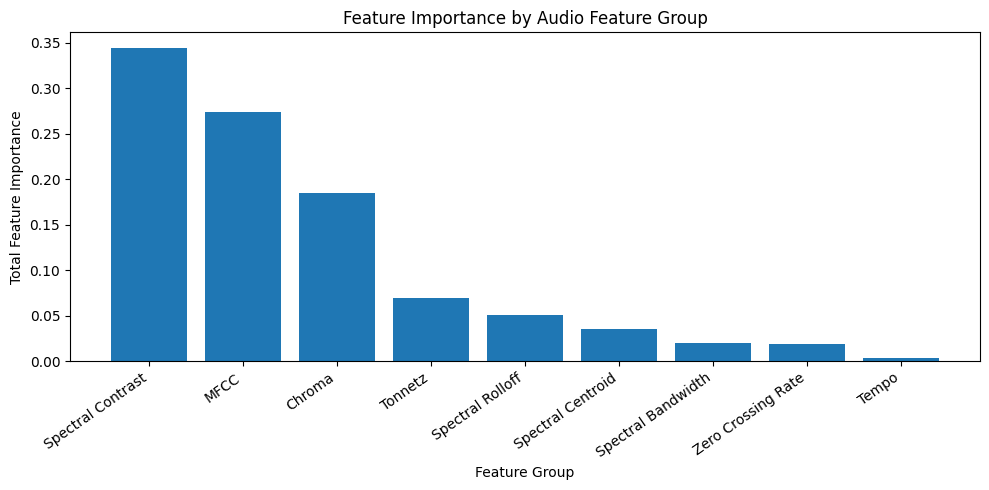

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df["Feature Group"],
    importance_df["Importance"]
)

plt.title("Feature Importance by Audio Feature Group")
plt.xlabel("Feature Group")
plt.ylabel("Total Feature Importance")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

## Interpreting Feature Importance

The previous plot shows the importance of each individual feature. While useful, the feature indices themselves are difficult to interpret.

By grouping related features together, we can better understand which types of musical information contributed most to genre classification.

For example:

- **MFCCs** mainly describe timbre.
- **Chroma** and **Tonnetz** describe harmonic information.
- **Spectral features** describe the frequency distribution of the signal.
- **Tempo** represents rhythmic information.

This grouped visualization makes the contribution of different musical dimensions easier to understand.

## Observations

- Combining multiple handcrafted features improved classification performance.
- Different feature groups contributed complementary information.
- MFCCs remained among the most informative features.
- Harmonic and spectral descriptors further improved the model.
- Feature importance analysis increased the interpretability of the classifier.
- Feature fusion represents the strongest classical machine learning model developed in this project.

## Reflection

Feature fusion demonstrates that handcrafted audio descriptors often capture complementary information.

Instead of searching for a single "best" feature, combining multiple representations allows the model to exploit different aspects of the audio signal simultaneously.

However, this approach still relies on manually designed features.

Deep learning models, such as the CNN developed earlier in the project, learn their own representations automatically from the data.

Feature fusion therefore represents the strongest classical machine learning approach explored in this project.

## Week 11 Summary

This notebook introduced feature fusion as an advanced handcrafted feature engineering strategy.

We:

- extracted multiple complementary audio descriptors
- combined them into unified feature vectors
- trained a Random Forest classifier
- evaluated classification performance
- analyzed feature importance at both the individual and group level

The results demonstrate that combining complementary audio features improves classical machine learning performance.

This notebook represents the culmination of the handcrafted feature engineering approach before transitioning to fully learned feature representations in deep learning.